### Local (NVIDIA GeForce RTX 4070 Ti SUPER): qwen-image-edit-4bit

In [ ]:
# Скачать (4-bit, ~13GB):
# $env:HF_HUB_ENABLE_HF_TRANSFER="1"; $env:HF_TOKEN="/..."; python -c "from huggingface_hub import snapshot_download; snapshot_download('ovedrive/qwen-image-edit-4bit', local_dir='D:/huggingface/qwen-image-edit-4bit')"

In [1]:
from PIL import Image
import torch
from diffusers import QwenImageEditPipeline

pipe = QwenImageEditPipeline.from_pretrained(
    "D:/huggingface/qwen-image-edit-4bit", torch_dtype=torch.bfloat16)
pipe.enable_model_cpu_offload()

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

true_cfg_scale is passed as 4.0, but classifier-free guidance is not enabled since no negative_prompt is provided.


  0%|          | 0/8 [00:00<?, ?it/s]

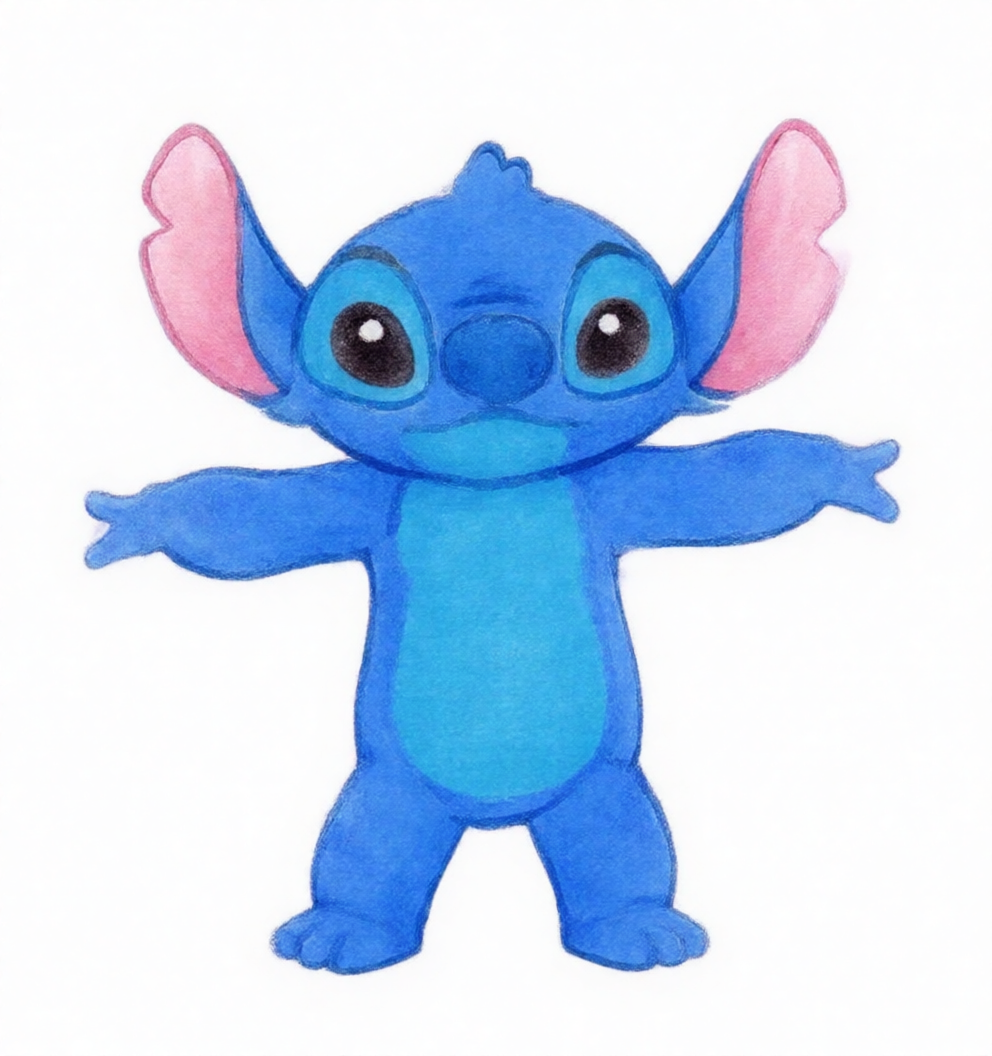

In [4]:
image = Image.open("OUTPUT/img04_clean.png").convert("RGB")

result = pipe(
    prompt="redraw this character standing in T-pose, arms spread horizontally, legs apart, facing forward, full body, white background",
    image=image,
    num_inference_steps=8,
).images[0]

result.save("OUTPUT/img04_tpose_qwen.png")
result


### OpenRouter: gemini-3.1-flash-image-preview

Status: 200


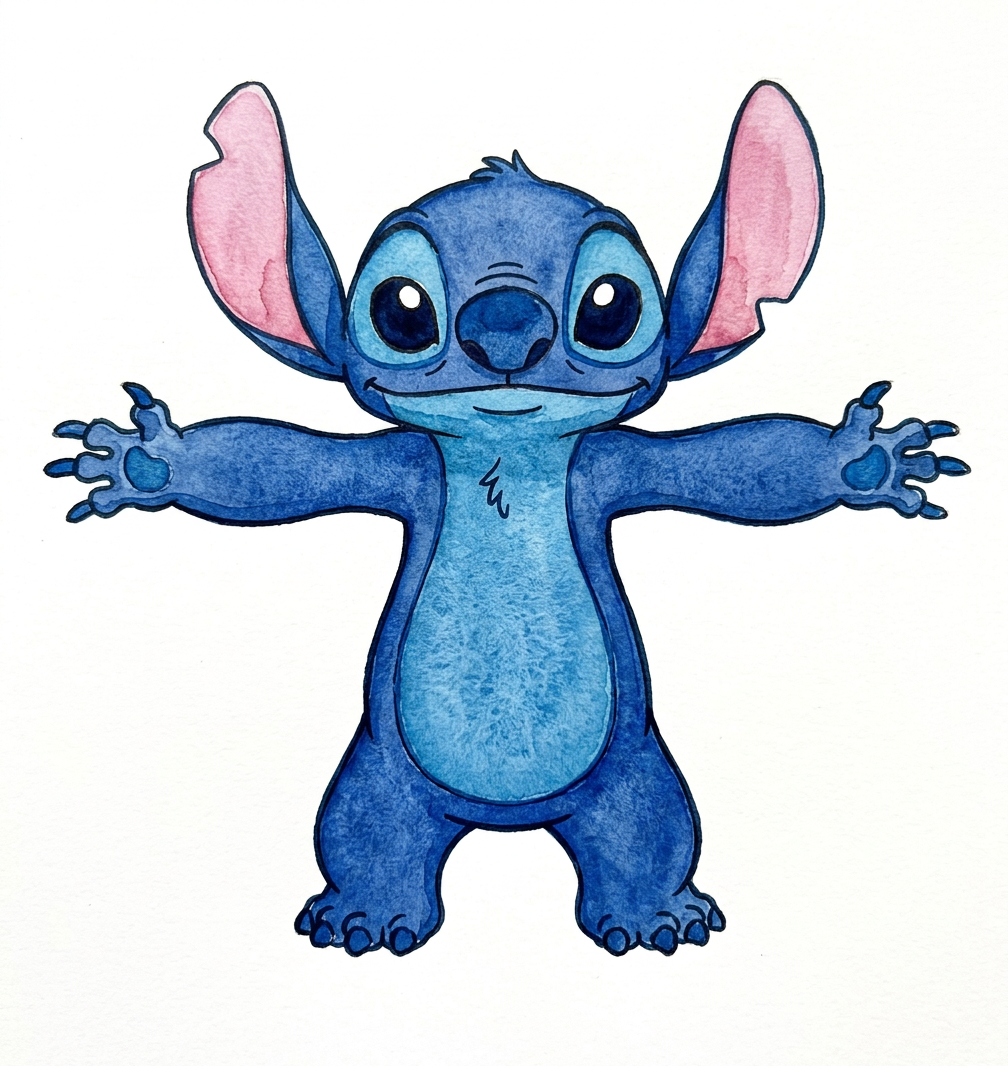

In [ ]:
import requests, base64
from io import BytesIO
from dotenv import load_dotenv

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")

# Конвертируем в JPEG (как в renovation боте)
ref = Image.open("OUTPUT/img04_clean.png").convert("RGB")
buf = BytesIO()
ref.save(buf, format="JPEG", quality=95)
img_b64 = base64.b64encode(buf.getvalue()).decode()

response = requests.post(
    "https://openrouter.ai/api/v1/chat/completions",
    headers={"Authorization": f"Bearer {OPENROUTER_API_KEY}", "Content-Type": "application/json"},
    json={
        # "model": "google/gemini-3-pro-image-preview",
        "model": "google/gemini-3.1-flash-image-preview",
        "messages": [{"role": "user", "content": [
            {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{img_b64}"}},
            {"type": "text", "text": ("Create a new original character inspired by the art style, color palette "
                                       "and proportions of the character in this image. "
                                       "The new character should stand in T-pose: both arms extended straight "
                                       "out to the sides, legs apart, facing directly forward, full body visible "
                                       "head to toe, all limbs clearly separated. Plain white background.")},
        ]}],
        "modalities": ["image", "text"],
        "require": ["image"]
    },
    timeout=120,
)


data = response.json()
print("Status:", response.status_code)

images = data["choices"][0]["message"].get("images", [])
if images:
    img_url = images[0]["image_url"]["url"]
    b64_data = img_url.split(",", 1)[1] if "," in img_url else img_url
    result_gemini = Image.open(BytesIO(base64.b64decode(b64_data)))
    result_gemini.save("OUTPUT/img04_tpose_gemini.png")
    display(result_gemini)
else:
    print("No image in response:", data)
